In [1]:
import pandas as pd
from scipy import stats
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import scipy as sp
from sklearn.gaussian_process.kernels import DotProduct,Matern, WhiteKernel, ExpSineSquared
from sklearn.model_selection import train_test_split
from matplotlib.patches import Polygon
import re
import random
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import zscore
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
import joblib
from sklearn.ensemble import GradientBoostingRegressor

In [2]:
def plotout(regr,X_test,y_test,Title):
    predicty=regr.predict(X_test)
    feature_importance = regr.feature_importances_
    sorted_idx = np.argsort(feature_importance)
    pos = np.arange(sorted_idx.shape[0]) + 0.5
    fig = plt.figure(figsize=(5, 15))
    plt.subplot(2,1, 2)
    plt.barh(pos, feature_importance[sorted_idx], align="center")
    plt.yticks(pos, np.array(x.columns)[sorted_idx])
    plt.title(Title+ " Feature Importance")
    t=pd.DataFrame({'x':np.array(x.columns)[sorted_idx],'b':feature_importance[sorted_idx]})
    t.loc[t["b"]>0.01]["x"].values
    plt.axvline(0.01,c="red")
    plt.subplot(2,1, 1)
    plt.plot(predicty,y_test,'ro',alpha=0.2,color="blue")
    plt.xlabel("predicted", fontsize=15)
   # plt.ylim(0,20)
    #plt.xlim(0,20)
    plt.ylabel("observed", fontsize=15)
    plt.title(Title+ " Testing Set", fontsize=15)
    plt.show()
    
def learn(x,y,save,filename):
    scaler =StandardScaler().fit(x)
    x_z=scaler.transform(x)
    X_train, X_test, y_train, y_test = train_test_split(
             x_z, y, test_size=0.30, random_state=44)
    regr = RandomForestRegressor().fit(X_train, y_train)
    RF_trainscore = regr.score(X_train, y_train)
    print("Training set score_ "+str(RF_trainscore))
    RF_testscore = regr.score(X_test, y_test)
    print("Test set score_ "+str(RF_testscore))
    if save==True: 
        joblib.dump(regr, filename+".joblib") 
        joblib.dump(scaler, filename+ "_Scalar.joblib") 
    return(X_train, X_test, y_train, y_test,regr)

In [6]:
Varset= ['p_taper',
       'ball_berry_slope', 'Vcmax25', 'sla_top', 'p50_node_aroot','rs2',"year","month"]

In [3]:
samples=pd.read_csv('C:/Users/345578/Desktop/Tool_Kit/Re_ LHS sampling/LHS.sam.csv')

In [10]:
GPP=pd.read_csv("C:/Users/345578/Desktop/NewML/FATES_outputs/FATES_GPP11425.csv")

In [12]:
x=GPP.iloc[:,np.r_[5:49]] ###here skipping all but the first tminus
x=x[Varset]
y=GPP.iloc[:,3]*1e8

In [13]:
y

0          9.338787
1          9.244168
2          9.563288
3          9.057909
4          9.609621
            ...    
280990    10.158212
280991    10.228993
280992     9.948662
280993     9.871655
280994    10.438558
Name: FATES_GPP, Length: 280995, dtype: float64

Training set score_ 0.9990971550036055
Test set score_ 0.9936078532330284


C:\Users\345578\AppData\Local\Temp\ipykernel_3816\2313682491.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot(predicty,y_test,'ro',alpha=0.2,color="blue")


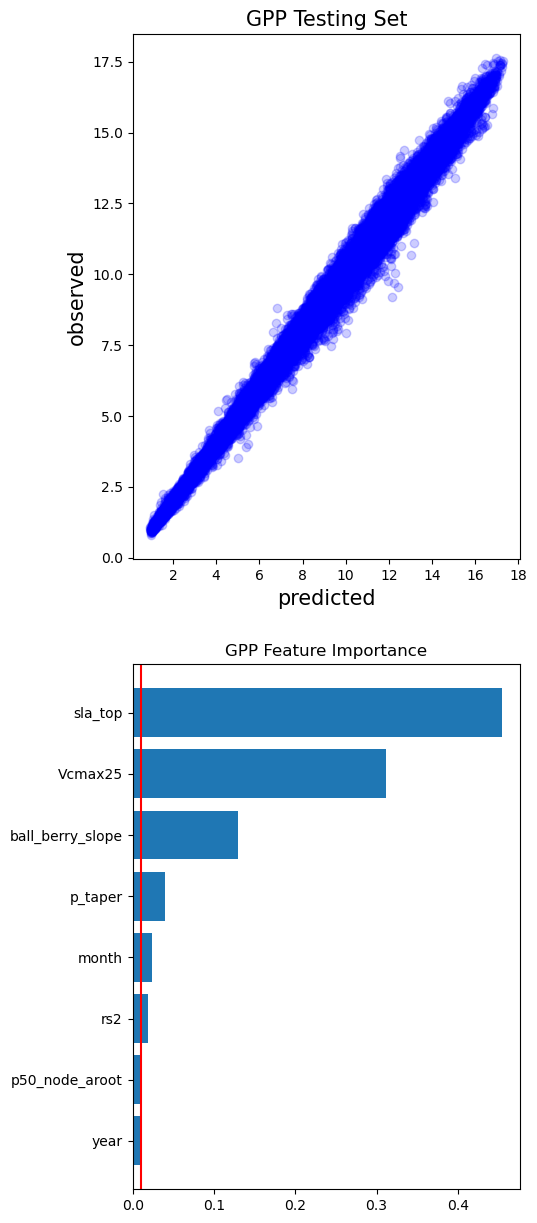

In [14]:
X_train, X_test, y_train, y_test,regr=learn(x,y,True,"GPP_minvar_031125")
plotout(regr,X_test,y_test,"GPP")

In [4]:
RO=pd.read_csv("C:/Users/345578/Desktop/NewML/FATES_outputs/QRUNOFF11425.csv")

In [7]:
x=RO.iloc[:,np.r_[5:49]] ###here skipping all but the first tminus
x=x[Varset]
y=RO.iloc[:,3]*1e6

In [8]:
y

0           1.703967
1           4.007992
2           3.158639
3           2.392504
4          11.233939
             ...    
280990    146.584056
280991     59.822015
280992    114.906077
280993     42.426779
280994     76.776135
Name: QRUNOFF, Length: 280995, dtype: float64

In [9]:
X_train, X_test, y_train, y_test,regr=learn(x,y,True,"RO_minvar_031125")
plotout(regr,X_test,y_test,"RO")

KeyboardInterrupt: 

In [16]:
H2oSOI1=pd.read_csv("C:/Users/345578/Desktop/NewML/FATES_outputs/H2OSOIvalue111425.csv")
x=H2oSOI1.iloc[:,np.r_[5:49]] ###here skipping all but the first tminus
x=x[Varset]
y=H2oSOI1.iloc[:,3]

Training set score_ 0.9942341169344109
Test set score_ 0.9591291898343307


C:\Users\345578\AppData\Local\Temp\ipykernel_62808\2313682491.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot(predicty,y_test,'ro',alpha=0.2,color="blue")


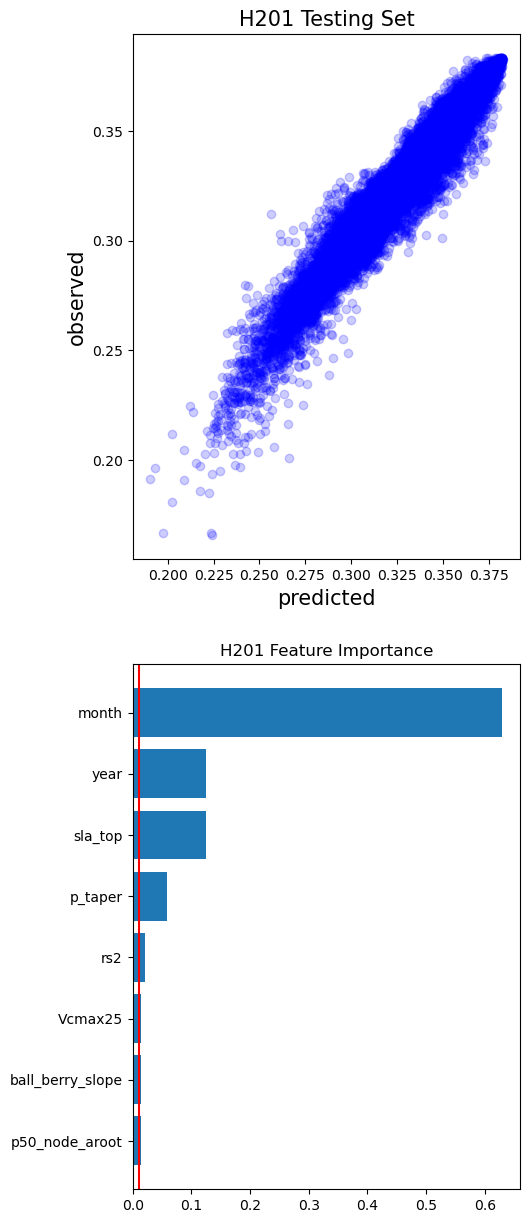

In [17]:
X_train, X_test, y_train, y_test,regr=learn(x,y,True,"H2oSOI1_minvar_012825")
plotout(regr,X_test,y_test, "H201")

In [18]:
H2oSOI1=pd.read_csv("C:/Users/345578/Desktop/NewML/FATES_outputs/H2OSOIvalue411425.csv")
x=H2oSOI1.iloc[:,np.r_[5:49]] ###here skipping all but the first tminus##here skipping all but the fir
x=x[Varset]
y=H2oSOI1.iloc[:,3]


Training set score_ 0.993933599625099
Test set score_ 0.9574984848343224


C:\Users\345578\AppData\Local\Temp\ipykernel_62808\2313682491.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot(predicty,y_test,'ro',alpha=0.2,color="blue")


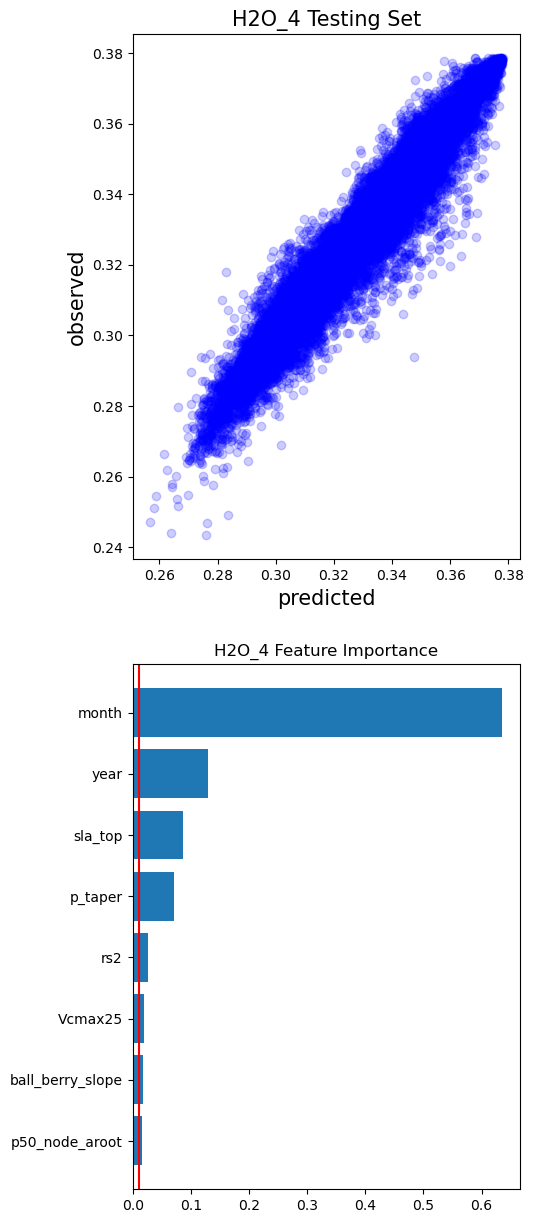

In [19]:
X_train, X_test, y_train, y_test,regr=learn(x,y,True,"H2oSOI4_minvar_012825")
plotout(regr,X_test,y_test,"H2O_4")

In [43]:
H2oSOI1=pd.read_csv("C:/Users/345578/Documents/GitHub/BCI_ML_tester/Outputs/ML_H2OSOIvalue4_7124.csv")
x=H2oSOI1.iloc[:,np.r_[9:53]] ###here skipping all but the first tminus
x=x[Varset]
y=H2oSOI1.iloc[:,3]


Training set score_ 0.9949162903459295
Test set score_ 0.9660903420238238


C:\Users\345578\AppData\Local\Temp\ipykernel_11820\3995932595.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot(predicty,y_test,'ro',alpha=0.2,color="blue")


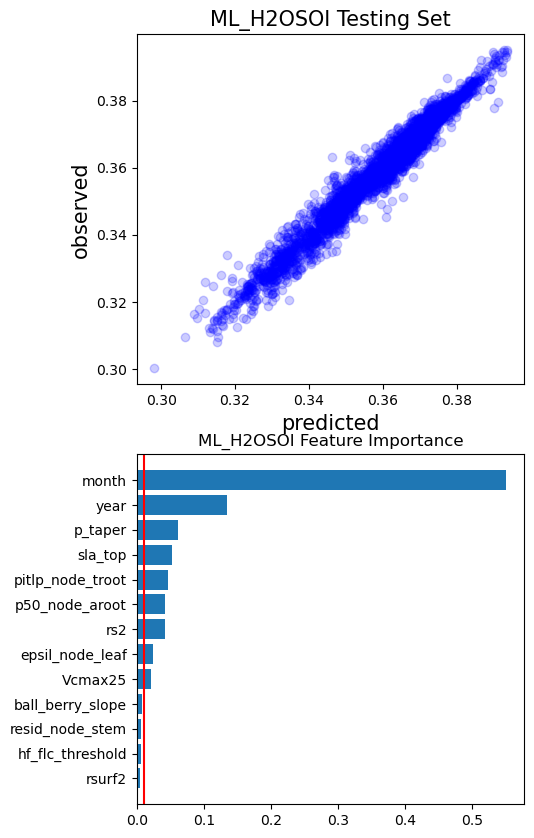

In [44]:
X_train, X_test, y_train, y_test,regr=learn(x,y,True,"H2oSOI7_minvar_012825")
plotout(regr,X_test,y_test,"ML_H2OSOI")


In [20]:
ET=pd.read_csv("C:/Users/345578/Desktop/NewML/FATES_outputs/ET11425.csv")
x=ET.iloc[:,np.r_[6:50]] ###here skipping all but the first tminus
x=x[Varset]

y=ET.iloc[:,50]*1e6

Training set score_ 0.9975812613009197
Test set score_ 0.9830991507138841


C:\Users\345578\AppData\Local\Temp\ipykernel_62808\2313682491.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot(predicty,y_test,'ro',alpha=0.2,color="blue")


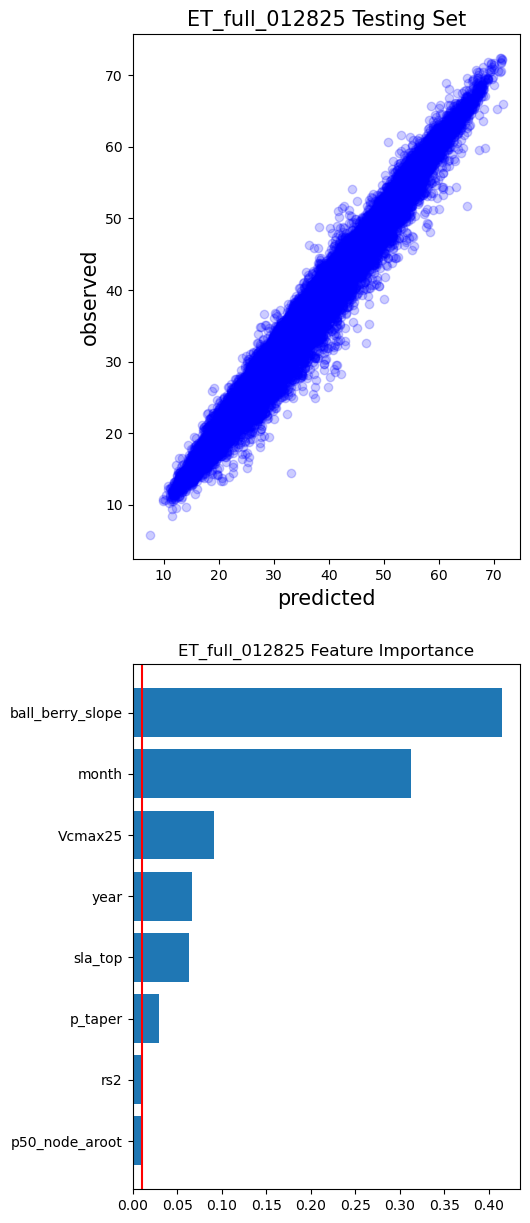

In [21]:
X_train, X_test, y_train, y_test,regr=learn(x,y,True,"ET_full_012825")
plotout(regr,X_test,y_test,"ET_full_012825")

In [4]:
Varset= ['p_taper',
       'ball_berry_slope', 'Vcmax25', 'sla_top', 'p50_node_aroot','rs2',"Year","DOY"]

Training set score_ 0.9998304092219814
Test set score_ 0.9988904998501874


C:\Users\345578\AppData\Local\Temp\ipykernel_62808\2313682491.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot(predicty,y_test,'ro',alpha=0.2,color="blue")


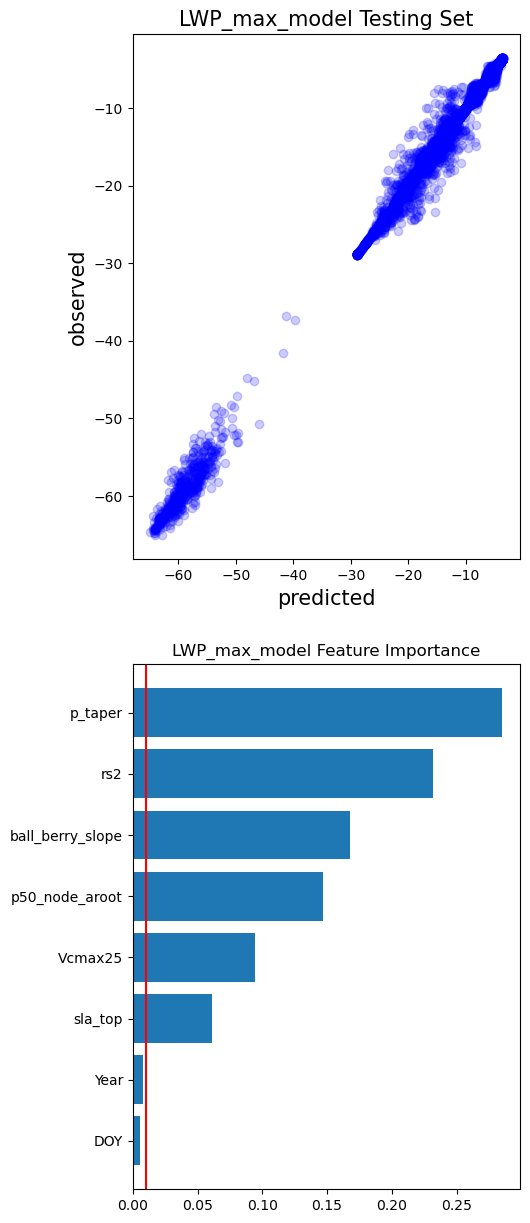

In [26]:
LWP=pd.read_csv("C:/Users/345578/Desktop/NewML/FATES_outputs/LWP_max11425.csv")
LWP["DOY"]=pd.DatetimeIndex(LWP['Date']).dayofyear
LWP["Year"]=pd.DatetimeIndex(LWP['Date']).year

x=LWP.iloc[:,np.r_[5:49]]
x=x[Varset]
y=LWP.iloc[:,3]*1e-5
X_train, X_test, y_train, y_test,regr=learn(x,y,True,"LWP_max_model_012825")
plotout(regr,X_test,y_test,"LWP_max_model")

Training set score_ 0.9940570167616398
Test set score_ 0.9574605498002359


C:\Users\345578\AppData\Local\Temp\ipykernel_65728\2313682491.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot(predicty,y_test,'ro',alpha=0.2,color="blue")


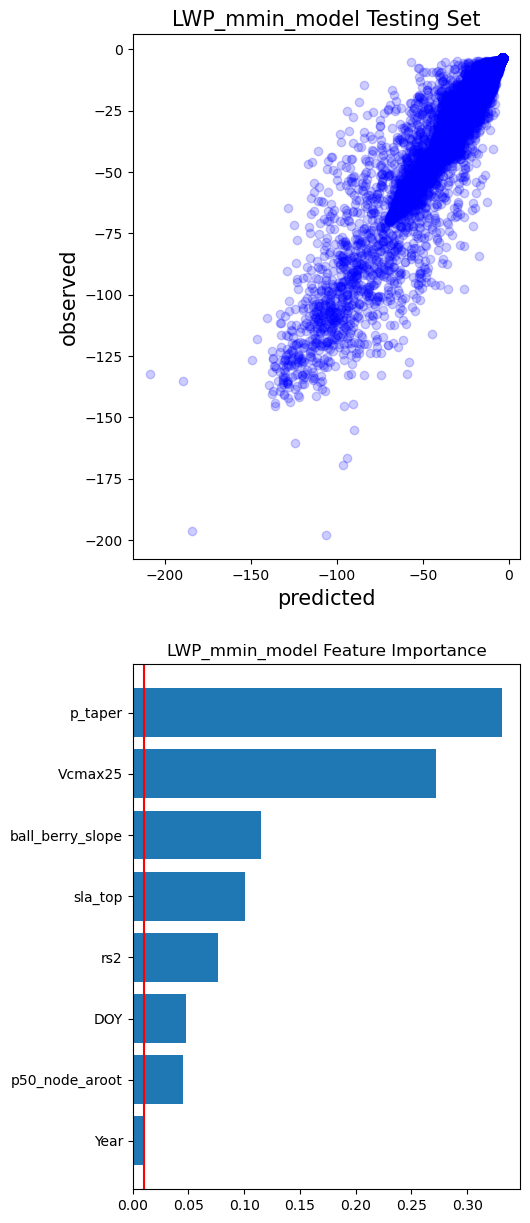

In [6]:
LWP=pd.read_csv("C:/Users/345578/Desktop/NewML/FATES_outputs/LWP_min11425.csv")
LWP["DOY"]=pd.DatetimeIndex(LWP['Date']).dayofyear
LWP["Year"]=pd.DatetimeIndex(LWP['Date']).year
x=LWP.iloc[:,np.r_[5:49]]
x=x[Varset]
y=LWP.iloc[:,3]*1e-5
X_train, X_test, y_train, y_test,regr=learn(x,y,True,"LWP_min_model_012825")
plotout(regr,X_test,y_test,"LWP_mmin_model")